In [23]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math

pd.set_option('display.max_columns', None)
data_path = '/data/home/yansn/naojiye/data/final_data/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)
filtered_df.shape

(887, 232)

In [ ]:
filtered_df = filtered_df[['Unnamed: 0', 'patientId','脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_降钙素原_定量','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']]

In [25]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
print("清洗后的列名:", filtered_df.columns.tolist())

清洗后的列名: ['Unnamed: 0', 'patientId', '脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量', '血_嗜酸性粒细胞百分比_定量', '血_降钙素原_定量', '血_乙型肝炎病毒核心抗体.IgM_定量', 'gender', 'age', '分组', '组名']


In [26]:
# 区分是否是脑膜炎：0是一类，1~6是一类

# 1. 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

# 去除病毒性脑炎（8）病状
filtered_df = filtered_df[filtered_df['分组']!=8]

# 选择特征 将数据正例和反例平均分配
filter_1 = filtered_df[filtered_df["分组"]==0]
filter_2= filtered_df[filtered_df["分组"].isin([1,2,3,4,5,6])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]

# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'] == 0).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'] == 0).astype(int) 

# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])

# 定义 Optuna 目标函数
def objective(trial):
    # 建议超参数范围
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42
        # 'scale_pos_weight':
    }
    
    # 创建模型
    model = xgb.XGBClassifier(**params)
    
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测验证集概率
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 计算 AUC
    auc_score = roc_auc_score(y_val, y_val_pred_proba)
    
    # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
    return 1.0 - auc_score

# 创建 Optuna 研究
study = optuna.create_study(
    direction='minimize',  # 最小化目标函数 (1 - AUC)
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
)

# 运行优化
print("开始超参数优化...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 输出最佳结果
print("\n优化完成!")
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
best_trial = study.best_trial
print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
print("  Best params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# 使用最佳参数重新训练最终模型
print("\n使用最佳参数训练最终模型...")
best_params = best_trial.params
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    auc = roc_auc_score(y, y_pred_proba)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # # 打印混淆矩阵
    # cm = confusion_matrix(y, y_pred)
    # print("Confusion Matrix:")
    # print(cm)
    
    return auc, accuracy, f1

# 评估训练集、验证集和测试集
train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

# 可选：保存最佳模型
# import joblib
# joblib.dump(final_model, 'best_xgb_model.pkl')
# print("\n最佳模型已保存为 'best_xgb_model.pkl'")

# 可选：绘制特征重要性
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# xgb.plot_importance(final_model, max_num_features=15)
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()

[I 2025-09-09 10:27:57,990] A new study created in memory with name: no-name-0d7cff26-a0ec-43a8-8c68-c78313cfd112


开始超参数优化...


Best trial: 0. Best value: 0.0704762:   1%|          | 1/100 [00:00<00:11,  8.89it/s]

[I 2025-09-09 10:27:58,102] Trial 0 finished with value: 0.07047619047619047 and parameters: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.07047619047619047.


Best trial: 2. Best value: 0.068254:   3%|▎         | 3/100 [00:01<00:33,  2.90it/s] 

...

[I 2025-09-09 10:28:29,661] Trial 94 finished with value: 0.060317460317460325 and parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.09473085846316233, 'subsample': 0.9621283687656347, 'colsample_bytree': 0.8140772890487257, 'reg_alpha': 2.6013190001328352, 'reg_lambda': 0.024258190676820973, 'min_child_weight': 2, 'gamma': 4.3308284131881924}. Best is trial 63 with value: 0.056984126984127026.
[I 2025-09-09 10:28:29,803] Trial 95 finished with value: 0.0573015873015873 and parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1333794619680722, 'subsample': 0.940052617052809, 'colsample_bytree': 0.7772148313136961, 'reg_alpha': 4.11493028703585, 'reg_lambda': 0.002049772025410257, 'min_child_weight': 2, 'gamma': 3.6486224169248156}. Best is trial 63 with value: 0.056984126984127026.


Best trial: 63. Best value: 0.0569841:  98%|█████████▊| 98/100 [00:32<00:00,  6.56it/s]

[I 2025-09-09 10:28:29,958] Trial 96 finished with value: 0.06873015873015864 and parameters: {'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.14239519759279837, 'subsample': 0.9427984875753129, 'colsample_bytree': 0.7738435586476946, 'reg_alpha': 0.5071028452912486, 'reg_lambda': 0.002230482530261872, 'min_child_weight': 2, 'gamma': 4.185080178158001}. Best is trial 63 with value: 0.056984126984127026.
[I 2025-09-09 10:28:30,096] Trial 97 finished with value: 0.060793650793650844 and parameters: {'n_estimators': 350, 'max_depth': 4, 'learning_rate': 0.08082498274866202, 'subsample': 0.9549605121239323, 'colsample_bytree': 0.7592877708098276, 'reg_alpha': 2.0349698843072934, 'reg_lambda': 0.00578479321868251, 'min_child_weight': 1, 'gamma': 3.848220702500477}. Best is trial 63 with value: 0.056984126984127026.


Best trial: 63. Best value: 0.0569841: 100%|██████████| 100/100 [00:34<00:00,  2.92it/s]


[I 2025-09-09 10:28:31,989] Trial 98 finished with value: 0.05888888888888888 and parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.10545855208437525, 'subsample': 0.979728350296817, 'colsample_bytree': 0.7888211611833835, 'reg_alpha': 3.263427376831239, 'reg_lambda': 0.00015106223233961617, 'min_child_weight': 2, 'gamma': 4.077790839806666}. Best is trial 63 with value: 0.056984126984127026.
[I 2025-09-09 10:28:32,183] Trial 99 finished with value: 0.059523809523809534 and parameters: {'n_estimators': 450, 'max_depth': 4, 'learning_rate': 0.12507235453005547, 'subsample': 0.8756156226856465, 'colsample_bytree': 0.80283207832315, 'reg_alpha': 3.3439231648626677, 'reg_lambda': 0.00021928897167859475, 'min_child_weight': 2, 'gamma': 4.0730112779120295}. Best is trial 63 with value: 0.056984126984127026.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9430
  Best params: 
    n_estimators: 300
    max_depth: 4
    learning_rate: 0.07333002887104072
    

matplotlib 识别的字体名: Songti SC
Validation Set Performance:
Accuracy: 0.8940
Precision: 0.7647
Recall: 0.5200
F1-Score: 0.6190

Test Set Performance:
Accuracy: 0.9079
Precision: 0.8235
Recall: 0.5600
F1-Score: 0.6667


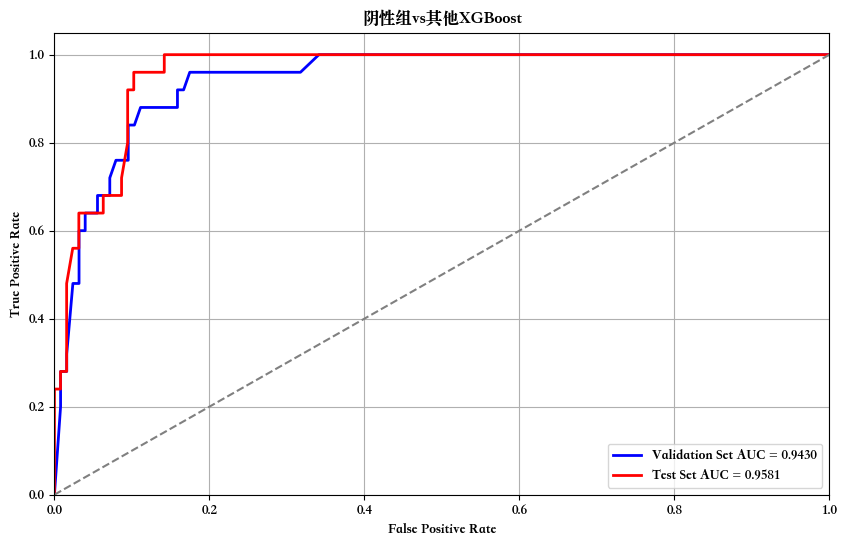

[0.894, 0.7647, 0.52, 0.619, 0.943, 0.9079, 0.8235, 0.56, 0.6667, 0.9581]

In [27]:
#注册中文字体到matplotlib
font_path = "/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 预测验证集和测试集
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# 预测验证集和测试集的概率（用于绘制 AUC 曲线）
y_val_prob = final_model.predict_proba(X_val)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# 计算准确率、精确率、召回率和F1分数
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

val_precision = precision_score(y_val, y_val_pred)
test_precision = precision_score(y_test, y_test_pred)

val_recall = recall_score(y_val, y_val_pred)
test_recall = recall_score(y_test, y_test_pred)

val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 输出模型评估结果
print("Validation Set Performance:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")

print("\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# 绘制 ROC 曲线和 AUC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# 计算 AUC
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation Set AUC = {roc_auc_val:.4f}')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test Set AUC = {roc_auc_test:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('阴性组vs其他XGBoost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

[round(val_accuracy,4),round(val_precision,4),round(val_recall,4),round(val_f1,4),round(roc_auc_val,4),round(test_accuracy,4),round(test_precision,4),round(test_recall,4),round(test_f1,4),round(roc_auc_test,4)]


===== SHAP 特征重要性 (柱状图):  =====


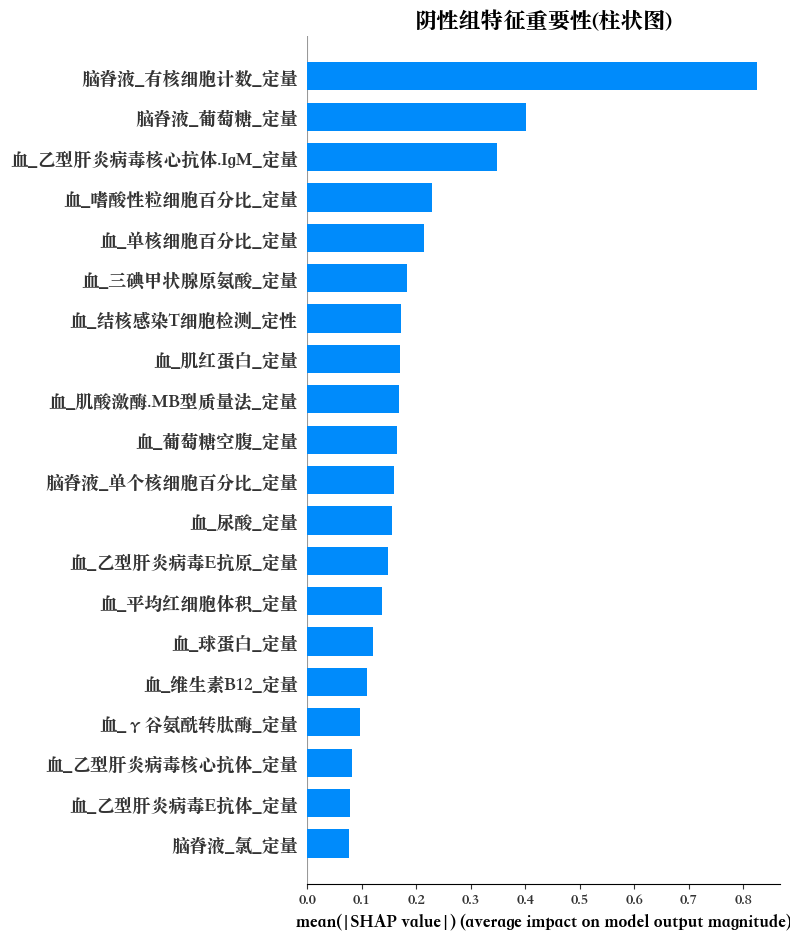


===== SHAP 特征分布 (蜂群图): =====


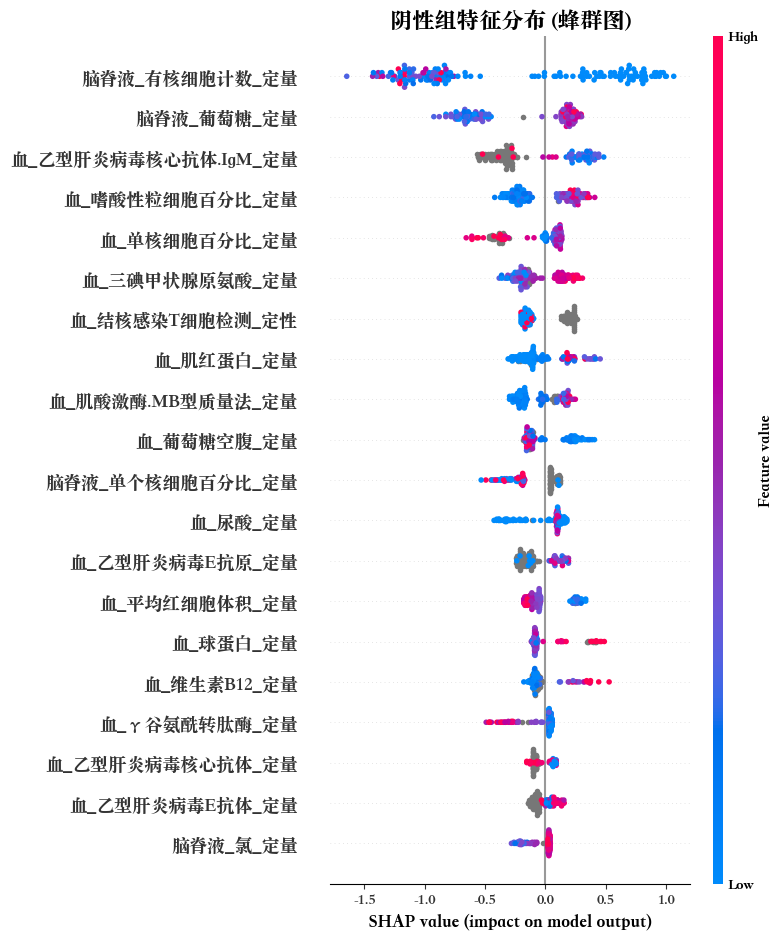

In [18]:

# ---------------- SHAP 分析 -----------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
plt.title("阴性组特征重要性(柱状图)", fontsize=16, fontweight='bold')
plt.tight_layout()
shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=True)
plt.title("阴性组特征分布 (蜂群图)", fontsize=16, fontweight='bold')
plt.tight_layout()

print(f"\n===== SHAP 特征分布 (蜂群图): =====")
shap.summary_plot(shap_matrix, X_test, show=True)


In [22]:
import pandas as pd
import numpy as np

# 计算每个特征的绝对 SHAP 值的平均值
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'shap_importance': np.abs(shap_values).mean(axis=0)
}).sort_values(by='shap_importance', ascending=False)

feature_importance.head(40)

,feature,shap_importance
207,脑脊液_有核细胞计数_定量,0.826437
210,脑脊液_葡萄糖_定量,0.400943
165,血_乙型肝炎病毒核心抗体.IgM_定量,0.347943
78,血_嗜酸性粒细胞百分比_定量,0.229347
65,血_单核细胞百分比_定量,0.214280
18,血_三碘甲状腺原氨酸_定量,0.182960
184,血_结核感染T细胞检测_定性,0.171569
12,血_肌红蛋白_定量,0.170408
9,血_肌酸激酶.MB型质量法_定量,0.168089
59,血_葡萄糖空腹_定量,0.163747


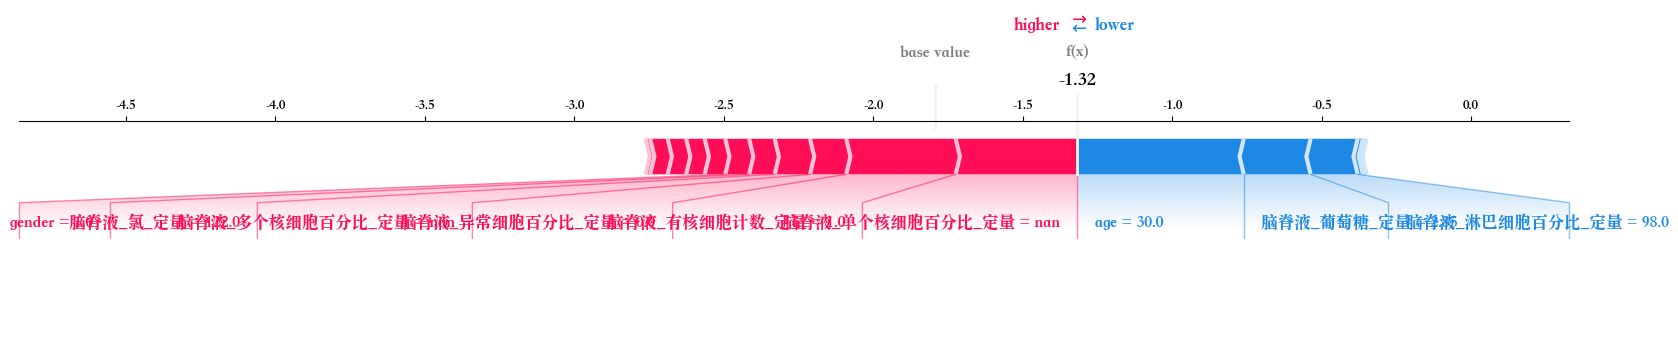

In [55]:
# 生成第一个样本的力导向图
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test.iloc[0, :], matplotlib=True)
plt.show()

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  fig.canvas.print_figure(bytes_io, **kw)


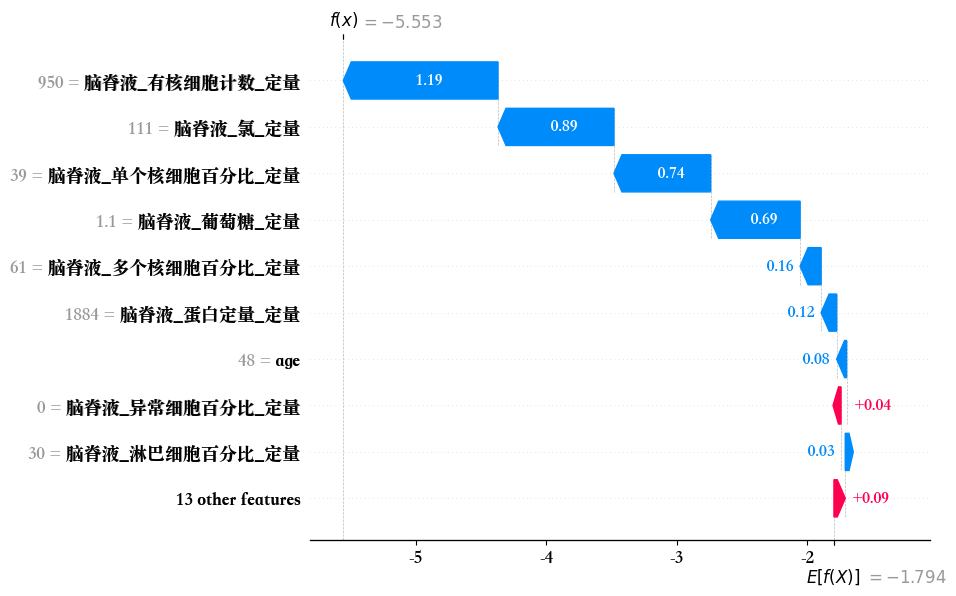

In [56]:
# 生成第一个样本的瀑布图
shap.plots.waterfall(shap.Explanation(values=shap_values[34], 
                                     base_values=explainer.expected_value, 
                                     data=X_test.iloc[34], 
                                     feature_names=X_val.columns))
plt.show()

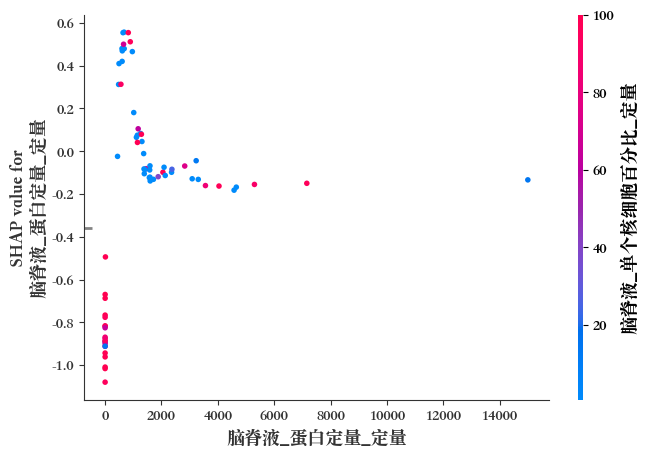

In [57]:
shap.dependence_plot('脑脊液_蛋白定量_定量', shap_values, X_test)